In [84]:
# Cell 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

- Image loaded: (3457, 3457)
- Image mode: L


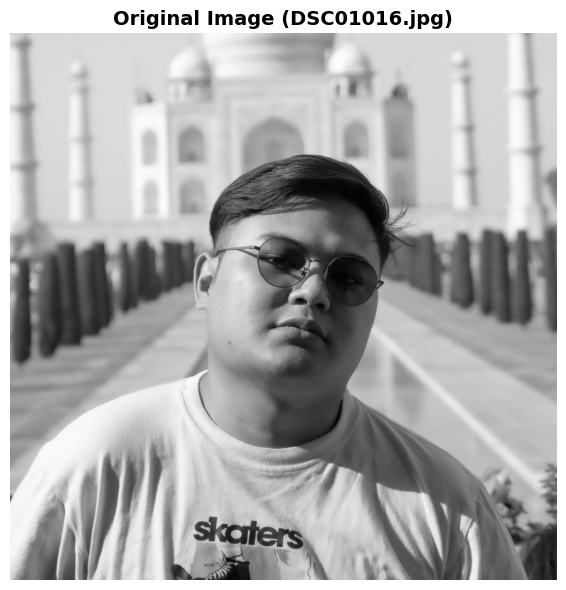

In [85]:
# Cell 2: Load Image
image_path = 'DSC01016.jpg'
original_image = Image.open(image_path)

if original_image.mode != 'L':
    original_image = original_image.convert('L')

print(f"- Image loaded: {original_image.size}")
print(f"- Image mode: {original_image.mode}")

plt.figure(figsize=(10, 6))
plt.imshow(original_image, cmap='gray')
plt.title('Original Image (DSC01016.jpg)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

Nilai Threshold Otsu: 139


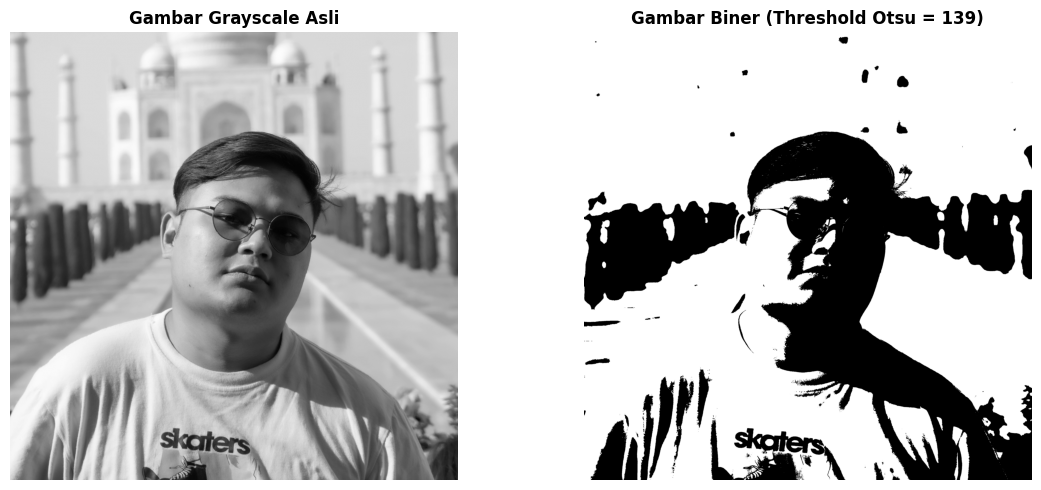

In [ ]:
# Cell 3: Otsu's Thresholding Implementation
def otsu_thresholding(image):
    """
    Implementasi Otsu's Thresholding.
    Menghitung threshold optimal berdasarkan histogram.
    """
    if isinstance(image, Image.Image):
        img_array = np.array(image)
    else:
        img_array = image
    
    # Flatten dan hitung histogram
    pixels = img_array.flatten()
    histogram = np.bincount(pixels, minlength=256).astype(float)
    histogram /= len(pixels)
    
    sum_total = np.sum(np.arange(256) * histogram)
    sum_background = 0
    weight_background = 0
    max_variance = 0
    optimal_threshold = 0
    
    # Cari threshold yang memaksimalkan variance
    for t in range(256):
        weight_background += histogram[t]
        
        if weight_background == 0 or weight_background == 1:
            continue
        
        sum_background += t * histogram[t]
        weight_foreground = 1 - weight_background
        
        mean_background = sum_background / weight_background
        mean_foreground = (sum_total - sum_background) / weight_foreground
        
        variance = weight_background * weight_foreground * \
                   (mean_background - mean_foreground) ** 2
        
        if variance > max_variance:
            max_variance = variance
            optimal_threshold = t
    
    return optimal_threshold

# Apply Otsu's thresholding
threshold_value = otsu_thresholding(original_image)
binary_image = (np.array(original_image) > threshold_value).astype(np.uint8) * 255

print(f"Nilai Threshold Otsu: {threshold_value}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Gambar Grayscale Asli', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_image, cmap='gray')
plt.title(f'Gambar Biner (Threshold Otsu = {threshold_value})', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

In [87]:
# Cell 4: Dilation - Morphological Operation
def dilation_optimized(image, kernel_size=3):
    """
    Dilation operation dengan NumPy vectorization.
    Memperluas white regions (nilai piksel akan bertambah).
    """
    img = np.array(image, dtype=np.uint8)
    pad = kernel_size // 2
    
    # Padding dengan 0 (black)
    padded = np.pad(img, ((pad, pad), (pad, pad)), mode='constant', constant_values=0)
    
    h, w = img.shape
    result = np.zeros((h, w), dtype=np.uint8)
    
    # Ambil nilai maksimum dari setiap window
    for i in range(kernel_size):
        for j in range(kernel_size):
            window = padded[i:i+h, j:j+w]
            result = np.maximum(result, window)
    
    return result

In [88]:
# Cell 5: Erosion - Morphological Operation
def erosion_optimized(image, kernel_size=3):
    """
    Erosion operation dengan NumPy vectorization.
    Menyusutkan white regions (nilai piksel akan berkurang).
    """
    img = np.array(image, dtype=np.uint8)
    pad = kernel_size // 2
    
    # Padding dengan 255 (white)
    padded = np.pad(img, ((pad, pad), (pad, pad)), mode='constant', constant_values=255)
    
    h, w = img.shape
    result = np.full((h, w), 255, dtype=np.uint8)
    
    # Ambil nilai minimum dari setiap window
    for i in range(kernel_size):
        for j in range(kernel_size):
            window = padded[i:i+h, j:j+w]
            result = np.minimum(result, window)
    
    return result

In [89]:
# Cell 6: Opening - Morphological Operation
def opening(image, kernel_size=3):
    """
    Opening: Erosion diikuti Dilation.
    Menghilangkan small white noise dan memisahkan objek yang terhubung lemah.
    """
    eroded = erosion_optimized(image, kernel_size)
    opened = dilation_optimized(eroded, kernel_size)
    return opened

In [90]:
# Cell 7: Closing - Morphological Operation
def closing(image, kernel_size=3):
    """
    Closing: Dilation diikuti Erosion.
    Menghilangkan small black holes dan menghubungkan objek terdekat.
    """
    dilated = dilation_optimized(image, kernel_size)
    closed = erosion_optimized(dilated, kernel_size)
    return closed

In [91]:
# Cell 8: Apply Morphological Operations
# Operasi dasar
dilated = dilation_optimized(binary_image, kernel_size=5)
eroded = erosion_optimized(binary_image, kernel_size=5)
opened = opening(binary_image, kernel_size=5)
closed = closing(binary_image, kernel_size=5)

# Kombinasi: Opening + Closing
combined_3x = closing(opening(binary_image, kernel_size=5), kernel_size=5)
for _ in range(2):  # Dua kali lagi untuk hasil yang lebih bersih
    combined_3x = closing(opening(combined_3x, kernel_size=5), kernel_size=5)

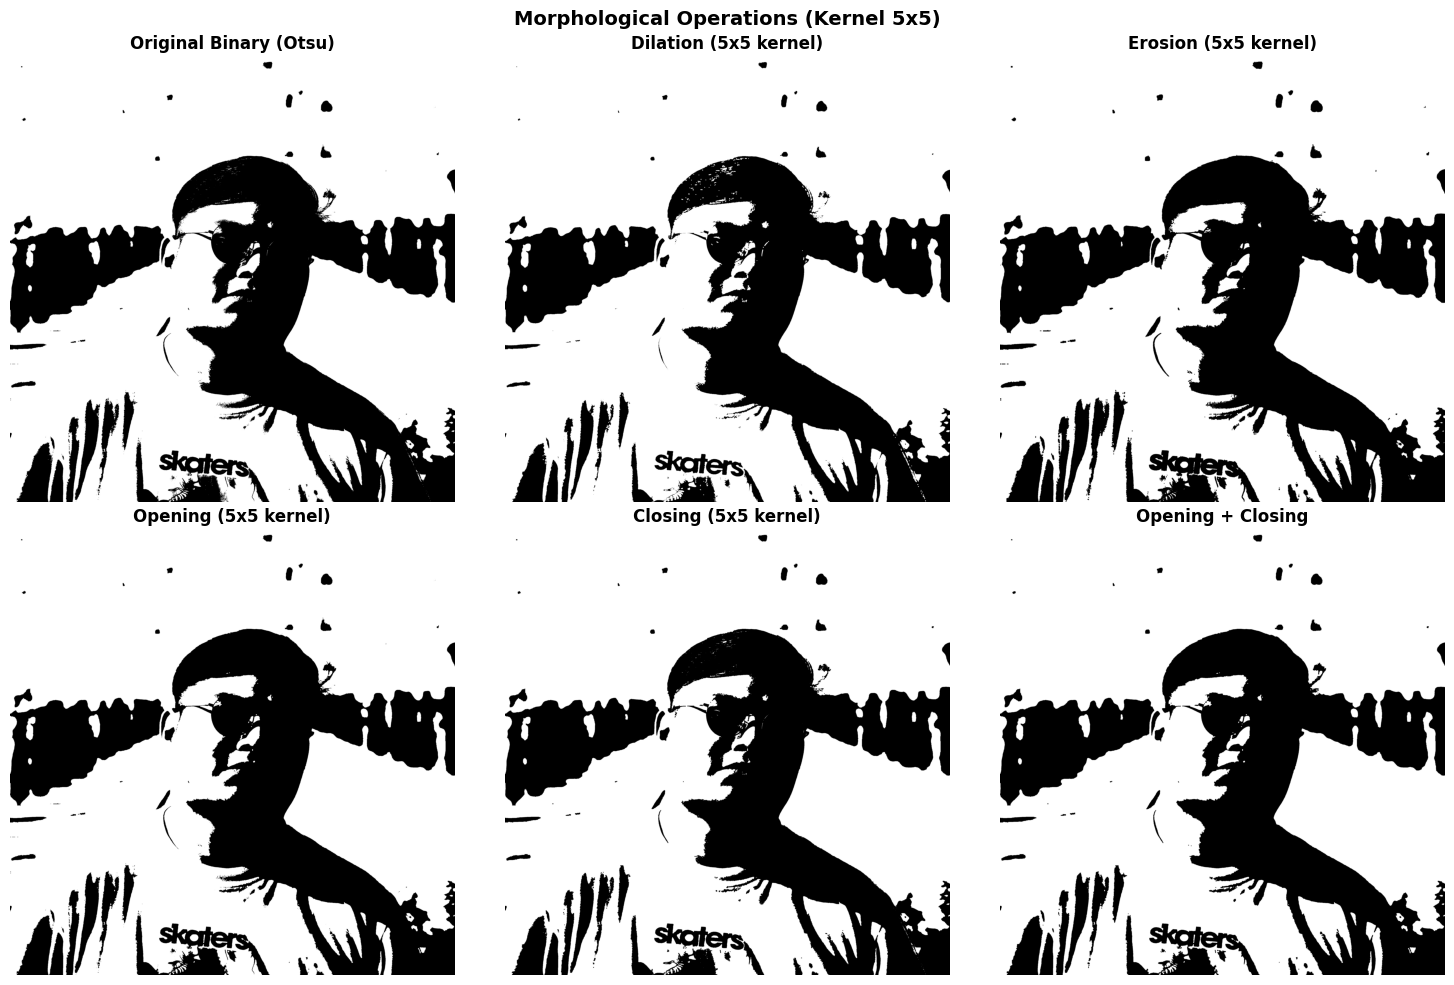

In [92]:
# Cell 9: Visualisasi - Operasi Dasar
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(binary_image, cmap='gray')
axes[0, 0].set_title('Original Binary (Otsu)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(dilated, cmap='gray')
axes[0, 1].set_title('Dilation (5x5 kernel)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(eroded, cmap='gray')
axes[0, 2].set_title('Erosion (5x5 kernel)', fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

axes[1, 0].imshow(opened, cmap='gray')
axes[1, 0].set_title('Opening (5x5 kernel)', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(closed, cmap='gray')
axes[1, 1].set_title('Closing (5x5 kernel)', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(combined_1x, cmap='gray')
axes[1, 2].set_title('Opening + Closing', fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle('Morphological Operations (Kernel 5x5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


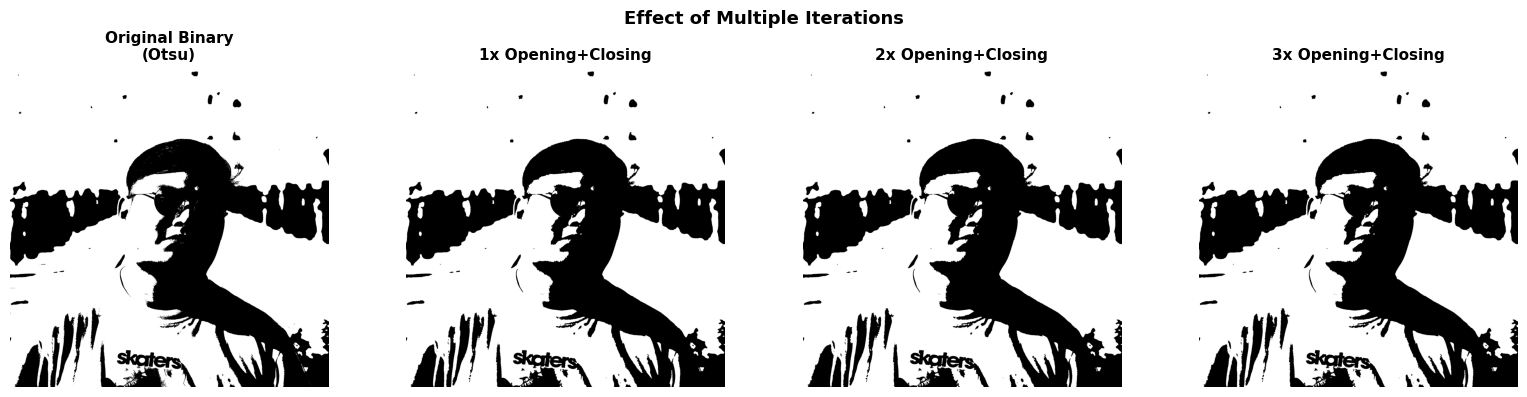

In [93]:
# Cell 10: Multiple Iterations
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(binary_image, cmap='gray')
axes[0].set_title('Original Binary\n(Otsu)', fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(combined_1x, cmap='gray')
axes[1].set_title('1x Opening+Closing', fontsize=11, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(combined_2x, cmap='gray')
axes[2].set_title('2x Opening+Closing', fontsize=11, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(combined_3x, cmap='gray')
axes[3].set_title('3x Opening+Closing', fontsize=11, fontweight='bold')
axes[3].axis('off')

plt.suptitle('Effect of Multiple Iterations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

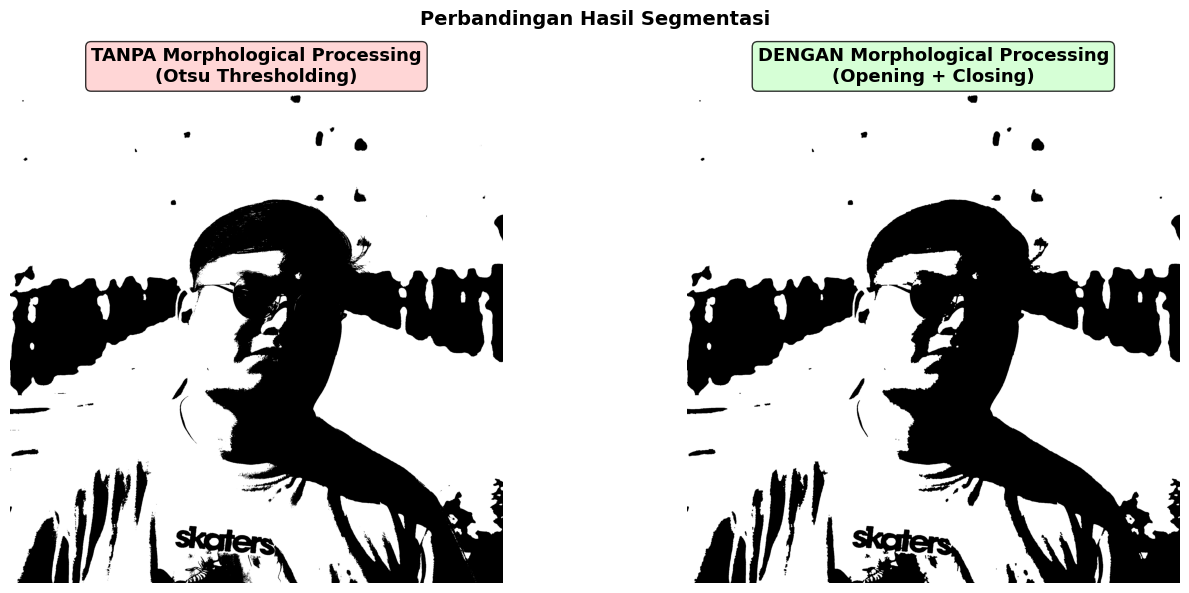

In [94]:
# Cell 11: Perbandingan Hasil Akhir
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(binary_image, cmap='gray')
axes[0].set_title('TANPA Morphological Processing\n(Otsu Thresholding)', 
                  fontsize=13, fontweight='bold',
                  bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.8))
axes[0].axis('off')

axes[1].imshow(combined_3x, cmap='gray')
axes[1].set_title('DENGAN Morphological Processing\n(Opening + Closing)', 
                  fontsize=13, fontweight='bold',
                  bbox=dict(boxstyle='round', facecolor='#ccffcc', alpha=0.8))
axes[1].axis('off')

plt.suptitle('Perbandingan Hasil Segmentasi', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### Kesimpulan

Berdasarkan perbandingan hasil di atas, dapat disimpulkan:

1. **Tanpa Morphological Processing:**
   - Hasil segmentasi menggunakan Otsu Thresholding masih memiliki noise dan detail yang tidak diinginkan
   - Objek utama masih terlihat kurang bersih dan terdapat area-area kecil yang mengganggu

2. **Dengan Morphological Processing:**
   - Kombinasi operasi Opening dan Closing berhasil membersihkan noise
   - Objek utama terlihat lebih jelas dan bersih
   - Bentuk objek tetap terjaga dengan baik

Morphological Processing terbukti efektif dalam meningkatkan kualitas hasil segmentasi dengan membersihkan noise tanpa menghilangkan informasi penting dari objek utama.